# Data Science Challenge

You are allowed to use any method in reading, loading, transforming the data. Additionally, you can use any model to predict the price of used cars. 

**Make sure** you explain your approach at each step, and to evaluate your model. Finally, you must show the Mean Asbolute Error from your model's predictions when compared with the test dataset's prices. 

---------------------------

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR 

pd.options.display.max_columns = 110

## Read Data

This section involves presenting the car datasets and their different columns and features. Both the 'train' and 'test' datasets are presented with their column names and first few rows of entries. 

In [2]:
# Reading both the 'train' and 'test' datasets
df_train = pd.read_csv('data_train.csv')
df_test = pd.read_csv('data_test.csv')

In [3]:
# Printing the 'train' dataset head
print("\nTrain Dataset:")
display(df_train.head())

# Printing the 'test' dataset head
print("\nTest Dataset:")
display(df_test.head())


Train Dataset:


,manufacturer_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_type,engine_capacity,body_type,has_warranty,ownership,type_of_drive,is_exchangeable,number_of_photos,number_of_maintenance,duration_listed,price_usd
0,Volkswagen,automatic,black,130000,2016,diesel,diesel,1.6,universal,False,owned,front,True,17,38,67,13150.0
1,Renault,manual,brown,149000,2012,gasoline,gasoline,1.6,sedan,False,owned,front,False,9,3,100,7500.0
2,Kia,automatic,brown,110000,2014,gasoline,gasoline,1.6,hatchback,False,owned,front,False,5,10,91,12200.0
3,Opel,automatic,other,255100,2007,gasoline,gasoline,1.8,hatchback,False,owned,front,False,10,4,91,4950.0
4,Mazda,manual,blue,650000,1999,gasoline,gasoline,2.0,sedan,False,owned,front,True,5,7,62,3000.0



Test Dataset:


,manufacturer_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_type,engine_capacity,body_type,has_warranty,ownership,type_of_drive,is_exchangeable,number_of_photos,number_of_maintenance,duration_listed,price_usd
0,BMW,automatic,white,115000,2012,gasoline,gasoline,4.4,sedan,False,owned,all,True,32,104,146,20450.0
1,Mercedes-Benz,manual,other,500000,1999,diesel,diesel,2.2,sedan,False,owned,rear,False,7,9,147,2600.0
2,Fiat,manual,silver,210000,2002,gasoline,gasoline,1.2,hatchback,False,owned,front,True,16,7,27,2900.0
3,Mitsubishi,automatic,violet,294000,2000,diesel,diesel,3.2,suv,False,owned,all,True,10,2,48,7500.0
4,Opel,automatic,blue,244000,1998,gasoline,gasoline,1.6,sedan,False,owned,front,False,9,10,116,2200.0


In [4]:
# Printing the 'train' dataset 
print('\nFull Train Dataset:')
display(df_train)

# Printing the 'test' dataset 
print('\nFull Test Dataset:')
display(df_test)


Full Train Dataset:


,manufacturer_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_type,engine_capacity,body_type,has_warranty,ownership,type_of_drive,is_exchangeable,number_of_photos,number_of_maintenance,duration_listed,price_usd
0,Volkswagen,automatic,black,130000,2016,diesel,diesel,1.6,universal,False,owned,front,True,17,38,67,13150.0
1,Renault,manual,brown,149000,2012,gasoline,gasoline,1.6,sedan,False,owned,front,False,9,3,100,7500.0
2,Kia,automatic,brown,110000,2014,gasoline,gasoline,1.6,hatchback,False,owned,front,False,5,10,91,12200.0
3,Opel,automatic,other,255100,2007,gasoline,gasoline,1.8,hatchback,False,owned,front,False,10,4,91,4950.0
4,Mazda,manual,blue,650000,1999,gasoline,gasoline,2.0,sedan,False,owned,front,True,5,7,62,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Opel,manual,white,380000,1996,gasoline,gasoline,1.6,sedan,False,owned,front,False,2,2,59,3500.0
49996,Volkswagen,manual,green,311213,1994,gas,gasoline,1.8,universal,False,owned,front,False,15,7,29,2850.0
49997,Fiat,manual,red,250000,1999,gasoline,gasoline,1.8,coupe,False,owned,front,False,7,13,108,2000.0
49998,BMW,automatic,grey,615000,1998,diesel,diesel,2.5,universal,False,owned,rear,True,10,26,64,5080.0



Full Test Dataset:


,manufacturer_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_type,engine_capacity,body_type,has_warranty,ownership,type_of_drive,is_exchangeable,number_of_photos,number_of_maintenance,duration_listed,price_usd
0,BMW,automatic,white,115000,2012,gasoline,gasoline,4.4,sedan,False,owned,all,True,32,104,146,20450.0
1,Mercedes-Benz,manual,other,500000,1999,diesel,diesel,2.2,sedan,False,owned,rear,False,7,9,147,2600.0
2,Fiat,manual,silver,210000,2002,gasoline,gasoline,1.2,hatchback,False,owned,front,True,16,7,27,2900.0
3,Mitsubishi,automatic,violet,294000,2000,diesel,diesel,3.2,suv,False,owned,all,True,10,2,48,7500.0
4,Opel,automatic,blue,244000,1998,gasoline,gasoline,1.6,sedan,False,owned,front,False,9,10,116,2200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26995,Volkswagen,manual,violet,92000,1993,gasoline,gasoline,2.0,hatchback,False,owned,front,False,13,11,65,3333.0
26996,Infiniti,automatic,silver,135185,2009,gas,gasoline,3.5,sedan,False,owned,all,False,8,2,85,8500.0
26997,Volkswagen,manual,white,450000,1993,gasoline,gasoline,1.8,sedan,False,owned,front,False,6,1,35,1100.0
26998,Audi,manual,grey,275000,2006,gasoline,gasoline,2.0,sedan,False,owned,front,False,7,28,115,6300.0


# 1. Data Preparation

An important step of the preprocessing stage is to understand and interpret the dataset correctly. This involves presenting the datasets different characteristics and identifying any missing values.

### 1.1 Train Data Characteristics

In [5]:
# Identifying the number of rows and columns in the dataset
print("Number of rows and columns:", df_train.shape)

# Identifying each columns datatype
print("\nColumn names and data types:")
print(df_train.dtypes)

# Printing the missing values in the dataset
print("\nMissing values:")
print(df_train.isnull().sum())

# Printing the statistical values of the dataset
print("\nSummary statistics:")
print(df_train.describe())

Number of rows and columns: (50000, 17)

Column names and data types:
manufacturer_name         object
transmission              object
color                     object
odometer_value             int64
year_produced              int64
engine_fuel               object
engine_type               object
engine_capacity          float64
body_type                 object
has_warranty                bool
ownership                 object
type_of_drive             object
is_exchangeable             bool
number_of_photos           int64
number_of_maintenance      int64
duration_listed            int64
price_usd                float64
dtype: object

Missing values:
manufacturer_name         0
transmission              0
color                     0
odometer_value            0
year_produced             0
engine_fuel               0
engine_type               0
engine_capacity          15
body_type                 0
has_warranty              0
ownership                 0
type_of_drive             0
is

In [6]:
# Finding all different manufacturer_name's
unique_car_makes = df_train['manufacturer_name'].unique()

# Finding all car colors
unique_car_colors = df_train['color'].unique()

# Finding all car drive types
unique_car_drive_types = df_train['type_of_drive'].unique()

# Printing all different manufacturer_name's
print("\nAll car manufacturers in the dataset:")
print(unique_car_makes)

# Printing all car colors
print("\nAll car colors in the dataset:")
print(unique_car_colors)

# Printing all car drive types
print("\nAll car drive types in the dataset:")
print(unique_car_drive_types)


All car manufacturers in the dataset:
['Volkswagen' 'Renault' 'Kia' 'Opel' 'Mazda' 'Hyundai' 'Mitsubishi'
 'Citroen' 'Peugeot' 'Dacia' 'ВАЗ' 'BMW' 'Fiat' 'Chevrolet' 'Audi'
 'Cadillac' 'Honda' 'Skoda' 'Toyota' 'Lexus' 'Mercedes-Benz' 'Volvo'
 'Lancia' 'Nissan' 'Ford' 'Chrysler' 'Москвич' 'Iveco' 'Jeep' 'Buick'
 'LADA' 'Jaguar' 'Rover' 'Dodge' 'Suzuki' 'SsangYong' 'Geely' 'УАЗ'
 'Daewoo' 'Alfa Romeo' 'Subaru' 'Infiniti' 'Saab' 'Mini' 'Chery' 'Seat'
 'Acura' 'Land Rover' 'ГАЗ' 'Lincoln' 'Pontiac' 'Lifan' 'Great Wall'
 'Porsche' 'ЗАЗ']

All car colors in the dataset:
['black' 'brown' 'other' 'blue' 'silver' 'red' 'white' 'green' 'grey'
 'orange' 'yellow' 'violet']

All car drive types in the dataset:
['front' 'rear' 'all']


### 1.2 Test Data Characteristics

In [7]:
# Identifying the number of rows and columns in the dataset
print("Number of rows and columns:", df_test.shape)

# Identifying each columns datatype
print("\nColumn names and data types:")
print(df_test.dtypes)

# Printing the missing values in the dataset
print("\nMissing values:")
print(df_test.isnull().sum())

# Printing the statistical values of the dataset
print("\nSummary statistics:")
print(df_test.describe())

Number of rows and columns: (27000, 17)

Column names and data types:
manufacturer_name         object
transmission              object
color                     object
odometer_value             int64
year_produced              int64
engine_fuel               object
engine_type               object
engine_capacity          float64
body_type                 object
has_warranty                bool
ownership                 object
type_of_drive             object
is_exchangeable             bool
number_of_photos           int64
number_of_maintenance      int64
duration_listed            int64
price_usd                float64
dtype: object

Missing values:
manufacturer_name        0
transmission             0
color                    0
odometer_value           0
year_produced            0
engine_fuel              0
engine_type              0
engine_capacity          5
body_type                0
has_warranty             0
ownership                0
type_of_drive            0
is_exchangeabl

### 1.3 Presenting the distribution of all numerical features in the 'train' dataset

This step involves identifying and visualising the distribution and frequency of all numerical values in the dataset using histograms.

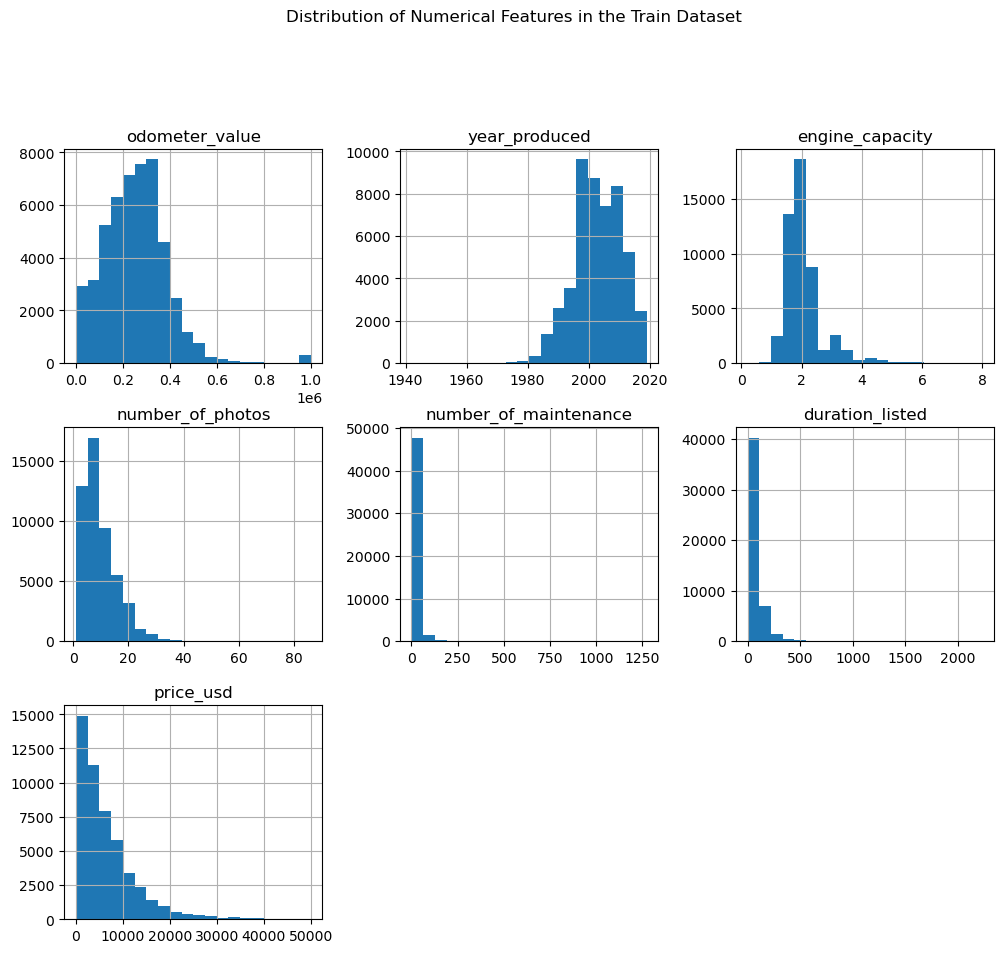

In [8]:
# Presenting each numerical feature's distribution
df_train.hist(figsize=(12, 10), bins=20)

plt.suptitle("Distribution of Numerical Features in the Train Dataset", y=1.02, fontsize=12)
plt.show()

## 1.4 Train Data Imputation

Considering the 'train' data contains missing values. These missing values need to be treated appropriately to ensure the regression algorithm performs well. I've used MICE as an imputation method to replace the missing values.

In [9]:
# Specifying engine_capacity as the column with missing values to impute
column_to_impute1 = 'engine_capacity'

# Implementing the Iterative Imputer(Mice Imputation)
MiceImputer = IterativeImputer(max_iter=10, random_state=42)

ImputedColumn1 = MiceImputer.fit_transform(df_train[[column_to_impute1]])

# Assigning the imputed values back to the column in the original dataFrame
df_train[column_to_impute1] = ImputedColumn1

#Printing the missing value count in each column of the train dataset
print("\nMissing values in the Train Dataset:")
print(df_train.isnull().sum())


Missing values in the Train Dataset:
manufacturer_name        0
transmission             0
color                    0
odometer_value           0
year_produced            0
engine_fuel              0
engine_type              0
engine_capacity          0
body_type                0
has_warranty             0
ownership                0
type_of_drive            0
is_exchangeable          0
number_of_photos         0
number_of_maintenance    0
duration_listed          0
price_usd                0
dtype: int64


## 1.5 Test data imputation

After imputing all missing values in the 'train' dataset, it's important to impute all missing values in the test dataset to ensure efficient model evaluation.

In [10]:
# Specifying engine_capacity as the column with missing values to impute
column_to_impute2 = 'engine_capacity'

ImputedColumn2 = MiceImputer.fit_transform(df_test[[column_to_impute2]])

# Assigning the imputed values back to the column in the original dataFrame
df_test[column_to_impute2] = ImputedColumn2

#Printing the missing value count in each column of the test dataset
print("\nMissing values in the Test dataset:")
print(df_test.isnull().sum())


Missing values in the Test dataset:
manufacturer_name        0
transmission             0
color                    0
odometer_value           0
year_produced            0
engine_fuel              0
engine_type              0
engine_capacity          0
body_type                0
has_warranty             0
ownership                0
type_of_drive            0
is_exchangeable          0
number_of_photos         0
number_of_maintenance    0
duration_listed          0
price_usd                0
dtype: int64


## 1.6 Encoding Categorical Features

Considering the datasets contains categorical features, this section involves encoding all features with 'object' datatypes to numerical values. I've applied this step because regression algorithms cannot directly handle non-numeric data, therefore they require numerical inputs. 

In [11]:
# Defining the categorical features in the dataset
cat_features = ['manufacturer_name', 'transmission', 'color', 'engine_fuel', 'engine_type', 'body_type', 'ownership', 'type_of_drive']

# Using LabelEncoder() to encode the categorical features
encoder = LabelEncoder()

# Encoding categorical features in the 'train' dataset using LabelEncoder
encoded_train = df_train[cat_features].apply(encoder.fit_transform)

# Combining the 'train' encoded features with the rest of the 'train' dataset
train_data_encoded = pd.concat([df_train.drop(cat_features, axis=1), encoded_train], axis=1)

# Encoding categorical features in the 'train' dataset using LabelEncoder
encoded_test = df_test[cat_features].apply(encoder.fit_transform)

# Combining the 'test' encoded features with the rest of the 'test' dataset
test_data_encoded = pd.concat([df_test.drop(cat_features, axis=1), encoded_test], axis=1)

# Displaying the new 'train' dataset values
print("\nTrain data encoded:")
print(train_data_encoded)

# Displaying the new 'test' dataset values
print("\nTest data encoded:")
print(test_data_encoded)


Train data encoded:
       odometer_value  year_produced  engine_capacity  has_warranty  \
0              130000           2016              1.6         False   
1              149000           2012              1.6         False   
2              110000           2014              1.6         False   
3              255100           2007              1.8         False   
4              650000           1999              2.0         False   
...               ...            ...              ...           ...   
49995          380000           1996              1.6         False   
49996          311213           1994              1.8         False   
49997          250000           1999              1.8         False   
49998          615000           1998              2.5         False   
49999          485000           2002              2.4         False   

       is_exchangeable  number_of_photos  number_of_maintenance  \
0                 True                17                   

## 1.7 Scaling/Normalising Numerical features in both Test and Train datasets

Scaling the data is a crucial step in machine learning because many algorithms are sensitive to the range and distribution of the features. Considering the datasets contain features that are on different scales (e.g., car mileage in thousands and car prices in tens of thousands), the algorithm may give disproportionate weight to features with larger values, which can lead to poor model performance. Therefore I've scaled/normalised the dataset the numerical features within the datasets. 

I've used MinMaxScaler as the scaling method because it maintains interpretablity. It works by transforming the data to a specific range between 0 and 1. This method preserves the relationships between values but compresses them into a smaller range.

In [12]:
# Defining the Numerical features in the datasets
numeric_features = ['odometer_value', 'year_produced', 'engine_capacity',
                    'number_of_photos','number_of_maintenance','duration_listed']

# Choosing a MinMaxScaler() as the scaler
scaler = MinMaxScaler()  

# Implementing the scaler and transforming the numeric features in both 'train' and 'test' datasets
train_data_encoded[numeric_features] = scaler.fit_transform(train_data_encoded[numeric_features])
test_data_encoded[numeric_features] = scaler.fit_transform(test_data_encoded[numeric_features])

# 2. Feature Selection

In this section I will be identifying the most relevant features to be included within the regression algorithm, filtering out features that may have no impact on the car prices.

## 2.1 Correlation heatmap

I begin feature selection by utilising a correlation heatmap to visualise the correlation between each feature in the 'train' dataset. This will present all features that negatively correlate or positively correlate towards the target variable (car price).

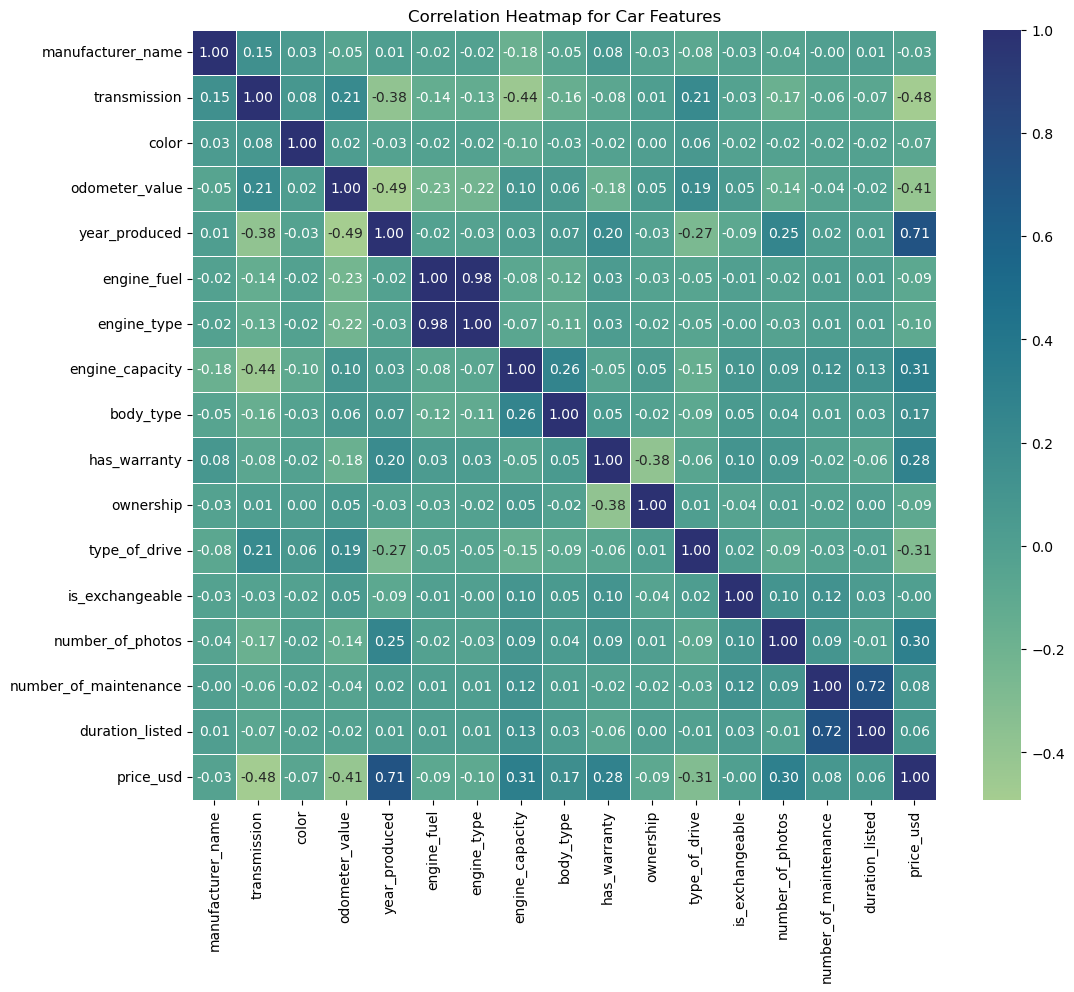

In [13]:
# Choosing a subset size for the heatmap dataset
subset_size = 5000

# Defining the subset within 'train' data
CarsSubset = train_data_encoded.sample(n=min(subset_size, len(train_data_encoded)))

# Defining all features to be included in the heatmap
HeatmapData = CarsSubset[['manufacturer_name', 'transmission','color','odometer_value', 'year_produced',
                          'engine_fuel','engine_type','engine_capacity','body_type','has_warranty',
                          'ownership','type_of_drive','is_exchangeable','number_of_photos',
                          'number_of_maintenance','duration_listed','price_usd']]

# Displaying the Correlation heatmap with their associated correlation values
plt.figure(figsize=(12, 10))
sns.heatmap(HeatmapData.corr(), annot=True, cmap='crest', linewidths=.5, fmt=".2f")
plt.title('Correlation Heatmap for Car Features')
plt.show()

## 2.3 Selected Features

Based on the correlation values of each feature and their real-world relevance to car prices, I've assessed the impact of each variable on predicting the car price and derived the following features play important roles in predicting the car price. 

- transmission: The heatmap shows that the transmission has a correlation index of -0.42, illustrating that this feature significantly effects the car price, despite having a negative effect on the car price, I believed it would be an important feature to include as it may be of benefit when using more complex regression models that identify non-linear and more complex underlying trends and patterns.   

- odometer_value: The heatmap shows that the odometer_value has a correlation index of -0.47, illustrating that this feature significantly effects the car price, despite having a negative effect on the car price, I believed it would be an important feature to include as it may be of benefit when using more complex regression models that identify non-linear and more complex underlying trends and patterns. This correlation index illustrates that a higher odometer value has a negative impact on car prices, as it is in the real world, where cars with a higher milage are lower valued.

- year_produced: The heatmap shows that the year_produced has a correlation index of 0.70, illustrating that this feature significantly correlates to the car price. This shows that newer cars have higher prices, as it is in the real world. 

- engine_type: The heatmap shows this feature to have a correlation index of -0.08, illustrating that it has a minimal affect on the car price. However, the car engine type usually has an affect on the car price in the real world, therefore I though it would be important to include incase more complex regression algorithms like Random Forest may identify underlying trends and patterns towards this feature.  

- engine_capacity: The heatmap shows this feature to have a correlation index of 0.31, illustrating that it has an affect on the car price, for that reason I've included this feature. 

- body_type: The heatmap shows this feature to have a correlation index of 0.18, illustrating that it has an affect on the car price, for that reason I've included this feature. 

- has_warranty: The heatmap shows this feature to have a correlation index of 0.27, illustrating that it has an impact on the car price, for that reason I've included this feature. 

- type_of_drive: The heatmap shows this feature to have a correlation index of -0.31, illustrating that it has a signiicantly negative impact on the car price. Considering it has an impact on the car price, I've included this feature for more complex algorithms like Random Forest Rgeression to identify underlying coomplex trends or patterns between this feature and the car price.

- number_of_photos: The heatmap shows this feature to have a correlation index of 0.31, illustrating that it has an impact on the car price, for that reason I've included this feature. 

- is_exchangeable: The heatmap shows this feature to have a correlation index of -0.01, illustrating that it has relatively no impact on the car price. However I've chosen to include this feature considering a cars exchangeable status is important in the real world.

- ownership: The heatmap shows this feature to have a correlation index of -0.07, illustrating that it has a relatevly small negative impact on the car price. The car's ownership status is also very important in the real world considering 'new' cars are usually more expensive and 'owned' or 'emergency' cars are usually prices low, for that reason I've included this feature. 


## 2.4 Unselected Features

- manufacturer_name: The heatmap shows this feature to have a correlation -0.03, illsutrating that this feature has little to no affect of the car price, for tha reason I chose not to include this feature.

- color: The heatmap shows this feature to have a correlation -0.06, illsutrating that this feature has little to no affect of the car price, for tha reason I chose not to include this feature.

- engine_fuel: The heatmap shows this feature to have a correlation -0.03, illsutrating that this feature has little to no affect of the car price, for tha reason I chose not to include this feature.

- number_of_maintenance: The heatmap shows this feature to have a correlation -0.07, illsutrating that this feature has little to no affect of the car price, for tha reason I chose not to include this feature.

- duration_listed: The heatmap shows this feature to have a correlation 0.04, illsutrating that this feature has little to no affect of the car price, for tha reason I chose not to include this feature.

# 3. Metric Selection

In this section I will make appropriate metric selection for analysing the regression model's performance.

- Mean Absolute Error(MAE): I'm using MAE as the first metric as it measures the average absolute difference between predicted and actual values, providing a straightforward interpretation of error in the same units as the target variable.
    
- R-squared: I'm using R squared as a second metric to strengthen the regression models performance score. R squared is a statistical value between 0 and 1 that predicts the accuracy of the regression model by taking the datapoints and finding the line of best fit. It represents the level of variablity explained by the model. This statistical value will determine the accuracy of the predicted values compared to the actual values and will act as a second performance score to evaluate and compare. Especially since the score is between 0 and 1 it allows myself to understand and scale accuracy level in the regression model

# 4. Dataset test/train split

Considering the datasets provided are already split into separate test and train datasets, this takes away the need to perform test and train splits to the existing datasets. I will use the 'train' dataset to train the regression algorithm and the 'test' dataset to test the regression algorithm performance.

# 5. Regression models

In this section I'll be experimenting with three different regression models to find the regression model with the highest prediction accuracy for the dataset at hand. I'll be using Linear Regression, Random Forest Regression and Support Vector Regression and evaluate their performance on the 'test' dataset. I'll be applying regression model optimisation tools such as cross validation and hyperparameter tuning to optimise the performance each regression model. Based on each regression models performance, I'll find the best and most accurate regression model to predict the car prices based on their features.  

## 5.1 Linear Regression model

Linear regression is a simple machine learning algorithm that models the relationship between the dependent variable and the independent variables by fitting a straight line. It assumes a linear relationship between the input features and the target variable. In this case, I'll use linear regression to explore linear relationships between the many different car features and the car price, leveraging existing linear relationships to predict car prices based on their features and evaluating it's performance on the 'test' dataset. Considering Linear regression does not contain tunable hyperparameters, the regression model will not run through hyperparameter tuning and therefore will be used as a baseline and a reference point for the following regression models explored. 

Mean Absolute Error (MAE): 2500.4670916280306
R-squared (R2): 0.6529172141966807


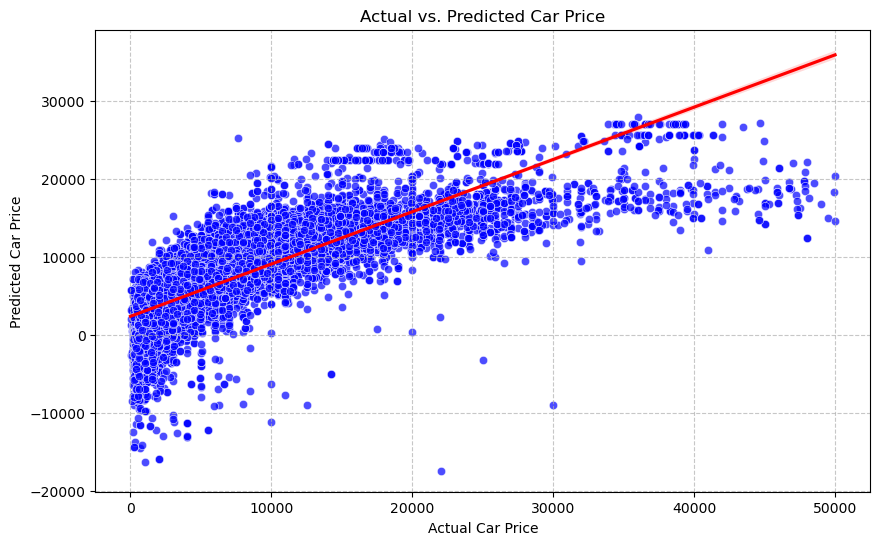

In [14]:
# defining the independant variables in the 'train' dataset
X_train = train_data_encoded.drop(columns=['price_usd','manufacturer_name','color' ,
                                           'engine_fuel', 'duration_listed'])  

# defining the target variable in the 'train' dataset
y_train = train_data_encoded['price_usd'] 

# defining the independant variables in the 'test' dataset
X_test = test_data_encoded.drop(columns=['price_usd','manufacturer_name','color' ,
                                           'engine_fuel', 'duration_listed'])  

# defining the target variable in the 'test' dataset
y_test = test_data_encoded['price_usd']  

# defining the Linear Regression model
LinearModel = LinearRegression()

# training the Linear Regression model on the 'train' dataset
LinearModel.fit(X_train, y_train)

# using the regression model to make predictions on the 'test' dataset
y_pred = LinearModel.predict(X_test)

# defining the performance metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R2): {r2}')

# displaying a scatterplot of the Regression Model's performance
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red')

plt.xlabel('Actual Car Price')
plt.ylabel('Predicted Car Price')
plt.title('Actual vs. Predicted Car Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5.1.1 Using Cross Validation to improve model accuracy

Cross validation is a technique used to evaluate the performance of a machine learning model by splitting the dataset into multiple subsets or "folds." The model is trained on some folds and tested on the remaining fold, repeating the process to ensure all data is used for both training and testing. It helps prevent overfitting and provides a more reliable measure of model performance by assessing how well the model generalizes to unseen data. I'll use cross-validation with 10 splits to ensure that the model is trained and tested on different parts of the data multiple times. This will provide a robust estimate of model performance by averaging the results over all folds, reducing the impact of any single split's variability.

In [15]:
# defining 10 fold cross validation 
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Calculating the performance metrics for each fold in the 'train' dataset
mae_scores = -cross_val_score(LinearModel, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(LinearModel, X_train, y_train, cv=kf, scoring='r2')

# Printing the average performance metric across each fold
print(f'Average MAE: {mae_scores.mean()}')
print(f'Average R-squared: {r2_scores.mean()}')

Average MAE: 2486.865795752955
Average R-squared: 0.6501806082355334


## 5.1.2 Linear Regression Model Evaluation

Evaluating Linear regression's performance, it has an MAE value of 2500 and an R-squared value of 0.65 (before cross validation). The R-squared metric reflects the model performing with 65% accuracy, illustrating that it has an error rate of 35% which is considered high. After performing cross validation, the models performance increases slightely with an MAE value of 2486 and an R squared value of 65%. The MAE value decreases slightly hinting a lower error rate compared to before cross validation. However, the performance metrics reflect low accuracy and large error rates illustrating that the regression model fails to capture the underlying trends and patterns within the dataset as it may contain non-linear and complex relationships that this model cannot capture. 

# 5.2  Random Forest Regression model

Random Forest Regression is a machine learning algorithm that builds multiple decision trees and merges their predictions to improve accuracy and control overfitting. It works by randomly selecting subsets of features and data points to create diverse trees, which enhances the model's robustness. I'm using Random Forest Regression because it effectively handles non-linear and complex underlying trends and patterns, identifying complex relationships between the car features and the target variable (car price) to make predictions on the 'test' dataset. 

Mean Absolute Error (MAE): 993.1624448258525
R-squared: 0.92816103622982


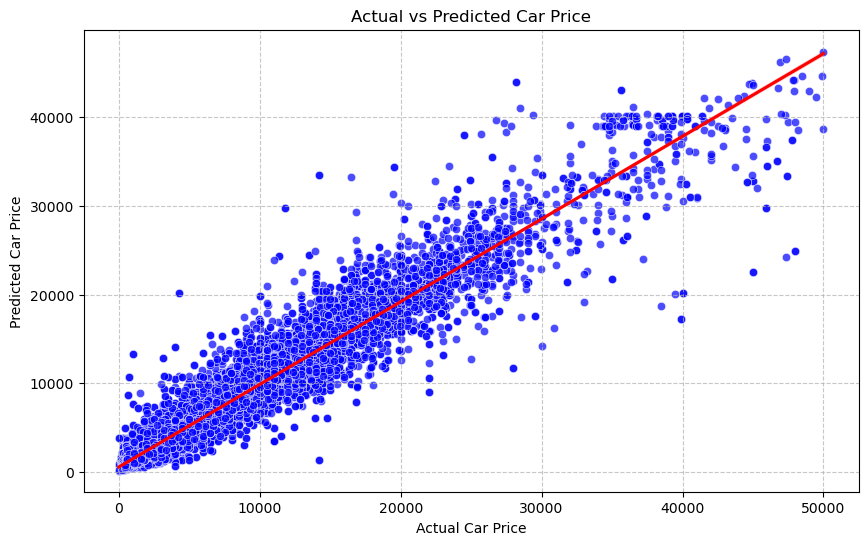

In [16]:
# defining the independant variables in the 'train' dataset
X_train = train_data_encoded.drop(columns=['price_usd','manufacturer_name','color' ,
                                           'engine_fuel', 'duration_listed'])  

# defining the target variable in the 'train' dataset
y_train = train_data_encoded['price_usd']  

# defining the independant variables in the 'test' dataset
X_test = test_data_encoded.drop(columns=['price_usd','manufacturer_name','color' ,
                                           'engine_fuel', 'duration_listed'])  # Features for test dataset

# defining the target variable in the 'test' dataset
y_test = test_data_encoded['price_usd']  

# defining the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# training the Random forest Regression model
rf_model.fit(X_train, y_train)

# implementing the regression model to make predictions on the 'test' dataset
y_pred = rf_model.predict(X_test)

# defining the performance metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared: {r2}')

# displaying a scatterplot of the Regression Model's performance
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red')

plt.xlabel('Actual Car Price')
plt.ylabel('Predicted Car Price')
plt.title('Actual vs Predicted Car Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5.2.1 Using cross validation to improve model accuracy 

As mentioned previously, I'm applying cross validation to reduce overfitting or underfitting in each model and improve performance and accuracy. I'll be applying 10 fold cross validation the the Random Forest Regression model as I did to the Linear regression model earlier on and evaluate wethere it's performance improves.

In [17]:
# defining 10 fold cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Calculating the performance metrics for each fold in the 'train' dataset
mae_scores = -cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')

# Printing the average performance metric across each fold
print(f'Average MAE: {mae_scores.mean()}')
print(f'Average R-squared: {r2_scores.mean()}')

Average MAE: 867.044710477554
Average R-squared: 0.9368627989991587


## 5.2.2 Using Grid Search to find the best hyperparameters

Grid search is a hyperparameter tuning technique that tests all possible combinations of a model's specified hyperparameters to find the best configuration. It systematically evaluates each combination through cross-validation, helping to identify the parameters that optimise model performance. I'll be using grid search to ensure that the Random Forest model is fine-tuned for accuracy an predictive power.

Sidenote: If the following block of code takes time to compute please feel free to skip running it, as it may require time and computational power to compute.

In [ ]:
# Choosing the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# defining the grid search to be applied on the Random Forest Model
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='r2', error_score='raise')

# training the model on the 'train' dataset
grid_search.fit(X_train, y_train)

# Defining the best hyperparameters
bestParams = grid_search.best_params_

# Implemented Random Forest with the best hyperparameters found
BestRFmodel = RandomForestRegressor(random_state=42, **bestParams)

# training the best model on the 'train' dataset
BestRFmodel.fit(X_train, y_train)

# implementing the regression model to make predictions on the 'test' dataset
y_pred = BestRFmodel.predict(X_test)

# defining the performance metrics
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print("Best parameters found:", grid_search.best_params_)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared Value: {r_squared}")

Reflecting on the grid search algorithm's performance, it has returned the best parameter's found for optimal accuracy. However, the hyperparameters returned produce an MAE value of 1006 and an R-squared value of 93%, an MAE value noticeably higher than it's performance prior to the grid search algorithm, hinting that the grid search algorithm has not suceeded in finding the best combination of hyperparemeters for the model. This may be because the algorithm is executed using 5 folds instead of 10, as shown earlier this algorithm performs best with more splits because it is a significantly large dataset. Due to time constraints and long computation times of this algorithm (few hours) I wasn't able to test this algorithm with more folds.  

## 5.2.3 Random Forest Model Evaluation

Evaluating random Forest's performance, it has an initial MAE value of 993 and an R-squared value of 0.92 (before cross validation). The R-squared metric reflects the model performing with 92% accuracy, illustrating that it has an error rate of 8% which is considered very low. After performing cross validation, the models performance increases with an MAE value of 867 and an R squared value of 93%. The MAE value decreases hinting a lower error rate compared to before cross validation. The overall performance reflecs high accuracy and low error rates illustrating that the regression model successfully captures the underlying trends and patterns within the dataset. This performance shows that the dataset contains non-linear and complex underlying relationships which is why Random forrest regression suits the dataset well.   


# 5.3 Support Vector Regression Model

Support Vector Regression (SVR) is a robust machine learning technique that builds upon the concepts of Support Vector Machines (SVM) for regression problems. This regression model identifies a hyperplane that optimally represents the data while allowing for a specified margin of error, finding a balance between model complexity and prediction accuracy. I’m using SVR because it is effective in capturing non-linear relationships through the use of kernel functions, making it suitable for complex datasets with intricate patterns. This will allow for exploring complex underlying relationships between the car features and the target variable (car prices), as well as tuning the model using it's kernel based on the linearity of the relationships present in the dataset.

## 5.3.1 Using a 'linear' kernel

Using a 'linear' kernel assumes the presence of linear relationships between the independant and target features within the dataset. I'll be using the 'linear' kernel to explore the presence of these relationships and evaluate prediction performance accuracy.

Mean Absolute Error (MAE): 3302.2770811059418
R-squared Value: 0.287872970521049


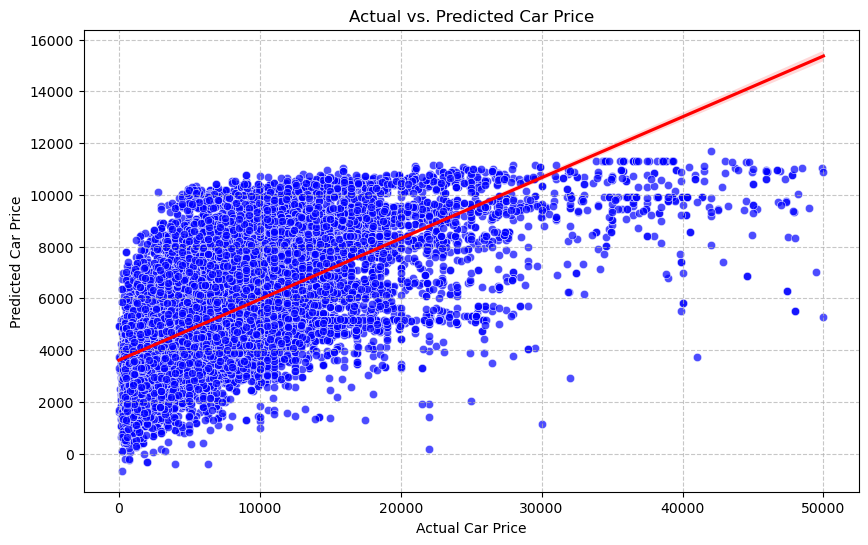

In [18]:
# defining the SVR Regression model with a 'linear' kernel
SVRmodel = SVR(kernel='linear')  

# training the SVR Regression model
SVRmodel.fit(X_train, y_train)

# making predictions on the 'test' dataset using the SVR model
y_pred = SVRmodel.predict(X_test)

# defining the performance metrics
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared Value: {r_squared}")

# displaying a scatterplot of the Regression Model's performance
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red')

plt.xlabel('Actual Car Price')
plt.ylabel('Predicted Car Price')
plt.title('Actual vs. Predicted Car Price')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5.3.2 Using an 'rbf' kernel

Using an 'rbf' kernel assumes the presence of non-linear and complex relationships between the independant features and target variable within the dataset. I'll be using the 'rbf' kernel to explore the presence of these relationships and evaluate prediction performance accuracy.

Mean Absolute Error (MAE): 4153.593544475952
R-squared Value: -0.01852382513953965


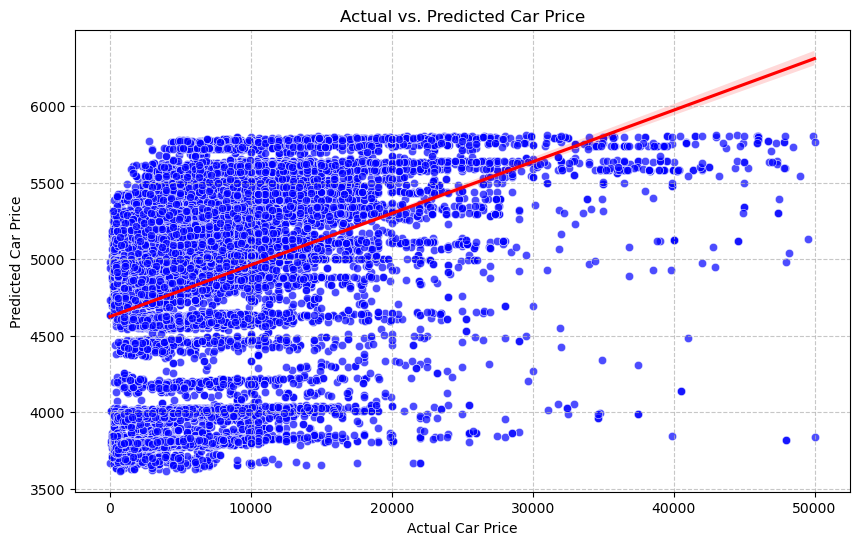

In [19]:
# defining the SVR Regression model with an 'rbf' kernel
SVRmodel = SVR(kernel='rbf') 

# training the SVR Regression model
SVRmodel.fit(X_train, y_train)

# making predictions on the 'test' dataset using the SVR model
y_pred = SVRmodel.predict(X_test)

# defining the performance metrics
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared Value: {r_squared}")

# displaying a scatterplot of the Regression Model's performance
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red')

plt.xlabel('Actual Car Price')
plt.ylabel('Predicted Car Price')
plt.title('Actual vs. Predicted Car Price')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5.3.3 Support Vector Regression Model Evaluation

Reflecting on the performance of Support Vector Regression, it produces an MAE of 3302 and an R-squared value of 0.28 with a linear kernel, and an MAE of 4153 of and an R-squared value of -0.01 with an rbf kernel. The performance metrics reflect little to no accuracy and very high error rates, illustrating that this regression model has failed to capture the underlying relationships within the dataset. The linear kernel performs the best out of both kernels, however an accuracy of 28% is still considered very low, especially when compared to the linear and random forest regression models.   

# 6. Conclusion

- Best regression model in predicting car prices: Random Forest Regression

- Model Error Rate (MAE): 867

- Model Accuracy Rate (R-Squared): 93%

Comparing the performance of all regression models in predicting car prices, Random Forest regression performs best with an MAE of 867 and an R-squared value of 0.93, Linear regression performs second best with an MAE of 2486 and an R-squared of 0.65, and Support Vector Regression performs the worst with an MAE of 3302 and an R-squared value of 0.28. This illustrates that Random forest Regression is model best tailored towards the datasets characteristics and feature relationships. Random forest Regression has a high prediction accuracy and a low error rate reflecting efficiency and robustness in handling the non-linear relationships between features. The model’s ability to capture complex interactions, combined with its relatively low tendency to overfit, makes it ideal for this dataset. While Linear Regression provides a simpler and more interpretable model, it struggles with the non-linear aspects of the data, leading to lower predictive accuracy. Support Vector Regression, though effective for certain tasks, seems less suitable for this dataset, potentially due to the difficulty in optimising hyperparameters or capturing the underlying feature interactions. Therefore, based on this analysis, Random Forest Regression stands out as the most suitable model for predicting car prices with high accuracy.

The aim of this project is to build a regression model to accurately predict the price of cars based on it's features. The aim has been achieved by evaluating and comparing multiple regression models, including Random Forest, Linear Regression, and Support Vector Regression, as well as applying model optimisation methods including cross validation and hyperparameter tuning. Through thorough analysis and performance metrics such as Mean Absolute Error (MAE) and R-squared values, Random Forest Regression was identified as the best-performing model. This model demonstrated high predictive accuracy and the ability to effectively capture complex feature interactions, achieving the project's goal of reliably predicting car prices based on their attributes. 